Episode   50 | Avg Reward (last 50): +24.16 | Avg Portfolio: $1241.61

⏹ Early stopping at episode 52 — no improvement > $1.0 in last 50 episodes.
   Best avg portfolio: $1243.33


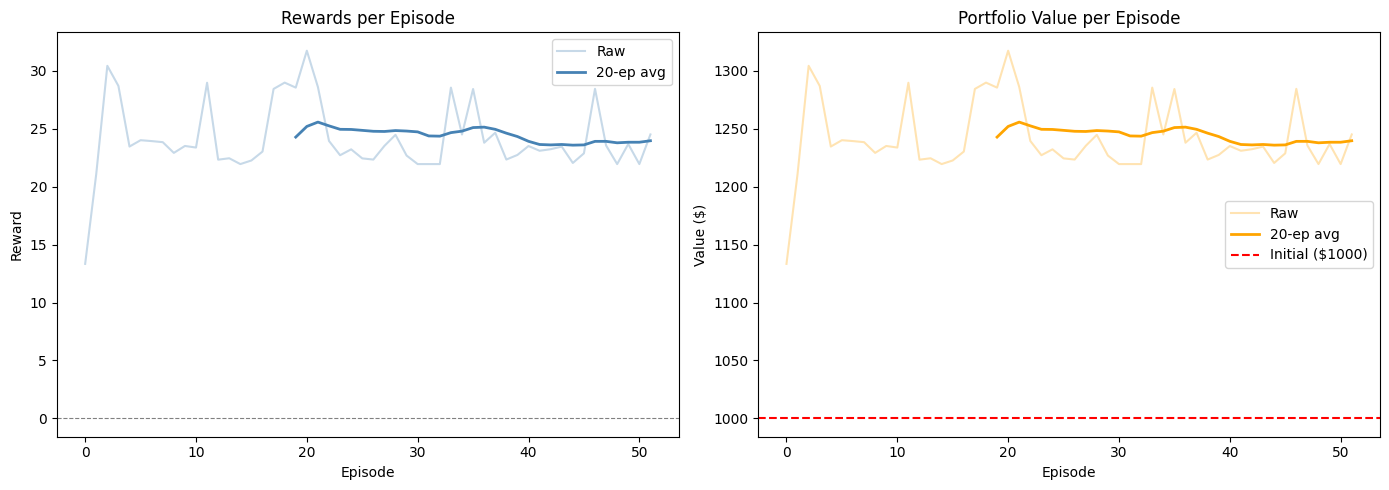

Done. Plot saved to training_results_improved.png


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -----------------------------
# 1. ENVIRONMENT
# -----------------------------
class TradingEnv:
    def __init__(self, prices):
        self.prices = prices
        self.n = len(prices)
        self.initial_cash = 1000
        self.reset()

    def reset(self):
        self.t = 5  # start at 5 so MA calculations don't underflow
        self.inventory = 0
        self.cash = self.initial_cash
        self.prev_value = self.initial_cash
        return self._get_state()

    def _get_state(self):
        t = min(self.t, self.n - 1)
        price     = self.prices[t]
        prev_price = self.prices[max(t - 1, 0)]
        ma5       = np.mean(self.prices[max(t - 4, 0):t + 1])
        ma10      = np.mean(self.prices[max(t - 9, 0):t + 1])
        momentum  = (price - prev_price) / 10.0       # 1-step change
        dev_ma5   = (price - ma5) / 10.0              # deviation from short MA
        dev_ma10  = (price - ma10) / 10.0             # deviation from long MA
        return np.array([
            price / 100.0,
            momentum,
            dev_ma5,
            dev_ma10,
            self.inventory / 10.0,
            self.cash / 1000.0
        ], dtype=np.float32)

    def step(self, action):
        price = self.prices[self.t]

        # 0=hold, 1=buy, 2=sell
        if action == 1:
            if self.cash >= price:
                self.inventory += 1
                self.cash -= price
        elif action == 2:
            if self.inventory > 0:
                self.inventory -= 1
                self.cash += price

        self.t += 1
        done = self.t >= self.n - 1

        next_t = min(self.t, self.n - 1)
        total_value = self.cash + self.inventory * self.prices[next_t]

        reward = (total_value - self.prev_value) / 10.0
        self.prev_value = total_value

        return self._get_state(), reward, done, total_value


# -----------------------------
# 2. MODEL (deeper network)
# -----------------------------
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.actor = nn.Sequential(
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Linear(64, 1)

    def forward(self, x):
        x = self.shared(x)
        return self.actor(x), self.critic(x)


# -----------------------------
# 3. TRAINING
# -----------------------------
def train(env, model, episodes=500, early_stop_window=50, early_stop_delta=1.0):
    """
    early_stop_window : number of episodes to average over
    early_stop_delta  : minimum improvement in avg portfolio to keep training
    """
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
    gamma = 0.99

    all_rewards = []
    portfolio_values = []
    best_avg_portfolio = -np.inf

    for ep in range(episodes):
        state = torch.tensor(env.reset(), dtype=torch.float32)
        done = False
        ep_reward = 0
        total_value = env.initial_cash

        while not done:
            probs, value = model(state)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            next_state, reward, done, total_value = env.step(action.item())
            next_state_t = torch.tensor(next_state, dtype=torch.float32)
            reward_t = torch.tensor(reward, dtype=torch.float32)

            with torch.no_grad():
                _, next_value = model(next_state_t)

            target = reward_t + gamma * next_value.squeeze() * (1 - int(done))
            advantage = target - value.squeeze()

            actor_loss = -dist.log_prob(action) * advantage.detach()
            critic_loss = advantage.pow(2)
            entropy = dist.entropy()

            loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()

            state = next_state_t
            ep_reward += reward_t.item()

        scheduler.step()
        all_rewards.append(ep_reward)
        portfolio_values.append(total_value)

        # Early stopping check (only after enough episodes)
        if (ep + 1) >= early_stop_window:
            avg_v = np.mean(portfolio_values[-early_stop_window:])
            avg_r = np.mean(all_rewards[-early_stop_window:])

            if (ep + 1) % 50 == 0:
                print(f"Episode {ep+1:>4} | Avg Reward (last {early_stop_window}): {avg_r:+.2f} | Avg Portfolio: ${avg_v:.2f}")

            if avg_v > best_avg_portfolio + early_stop_delta:
                best_avg_portfolio = avg_v  # improvement found, keep going
            else:
                print(f"\n⏹ Early stopping at episode {ep+1} — no improvement > ${early_stop_delta} in last {early_stop_window} episodes.")
                print(f"   Best avg portfolio: ${best_avg_portfolio:.2f}")
                break

    return all_rewards, portfolio_values


# -----------------------------
# 4. DATA — trending price with drift
# -----------------------------
np.random.seed(42)
prices = np.cumsum(np.random.randn(500) + 0.05) + 100  # upward drift, longer series

env   = TradingEnv(prices)
model = ActorCritic(state_dim=6, action_dim=3)

# -----------------------------
# 5. TRAIN
# -----------------------------
rewards, values = train(env, model, episodes=500, early_stop_window=50, early_stop_delta=1.0)

# -----------------------------
# 6. PLOTS
# -----------------------------
window = 20
def smooth(x, w):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward plot
axes[0].plot(rewards, alpha=0.3, color='steelblue', label='Raw')
axes[0].plot(range(window-1, len(rewards)), smooth(rewards, window),
             color='steelblue', linewidth=2, label=f'{window}-ep avg')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title("Rewards per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

# Portfolio plot
axes[1].plot(values, alpha=0.3, color='orange', label='Raw')
axes[1].plot(range(window-1, len(values)), smooth(values, window),
             color='orange', linewidth=2, label=f'{window}-ep avg')
axes[1].axhline(y=1000, color='red', linestyle='--', label='Initial ($1000)')
axes[1].set_title("Portfolio Value per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Value ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_results_improved.png", dpi=150)
plt.show()
print("Done. Plot saved to training_results_improved.png")